## **Package**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import yfinance as yf
from scipy.optimize import minimize
from joblib import Parallel, delayed

# 그림 저장 경로 (실행 디렉터리 기준 상대경로)
FIGURE_DIR = "./report/figure/"

## **S&P 500 Sector Data**

In [22]:

tickers = ["XLK","XLF","XLV","XLY","XLI","XLE","XLC","XLU","XLB","XLRE","XBI"]
data = yf.download(tickers, start="2010-01-01", interval="1mo")['Close']
weights = data.div(data.sum(axis=1), axis=0) 
print(weights.tail())


/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/748242483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01", interval="1mo")['Close']
[*********************100%***********************]  11 of 11 completed

Ticker           XBI       XLB       XLC       XLE       XLF       XLI  \
Date                                                                     
2025-07-01  0.065395  0.066678  0.081738  0.066034  0.039861  0.115603   
2025-08-01  0.066859  0.068362  0.082623  0.066711  0.040055  0.112680   
2025-09-01  0.072020  0.064129  0.084808  0.063689  0.038604  0.110430   
2025-10-01  0.079172  0.060178  0.080647  0.061906  0.036787  0.108920   
2025-11-01  0.076910  0.060309  0.080306  0.062068  0.037316  0.108638   

Ticker           XLK      XLRE       XLU       XLV       XLY  
Date                                                          
2025-07-01  0.200382  0.031383  0.064984  0.099148  0.168795  
2025-08-01  0.195099  0.031254  0.062342  0.101828  0.172187  
2025-09-01  0.202387  0.030061  0.062282  0.099603  0.171989  
2025-10-01  0.211210  0.028730  0.062587  0.101327  0.168536  
2025-11-01  0.209246  0.029144  0.063235  0.103292  0.169538  


## **S&P 500 Sector Figure**

/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/1667421454.py:28: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  wy = w.resample("Y").mean()


saved: /Users/hoseung/GoogleDrive/3-2/Mathematical Economics/Assignment/report/figure/snp_sector_index.png


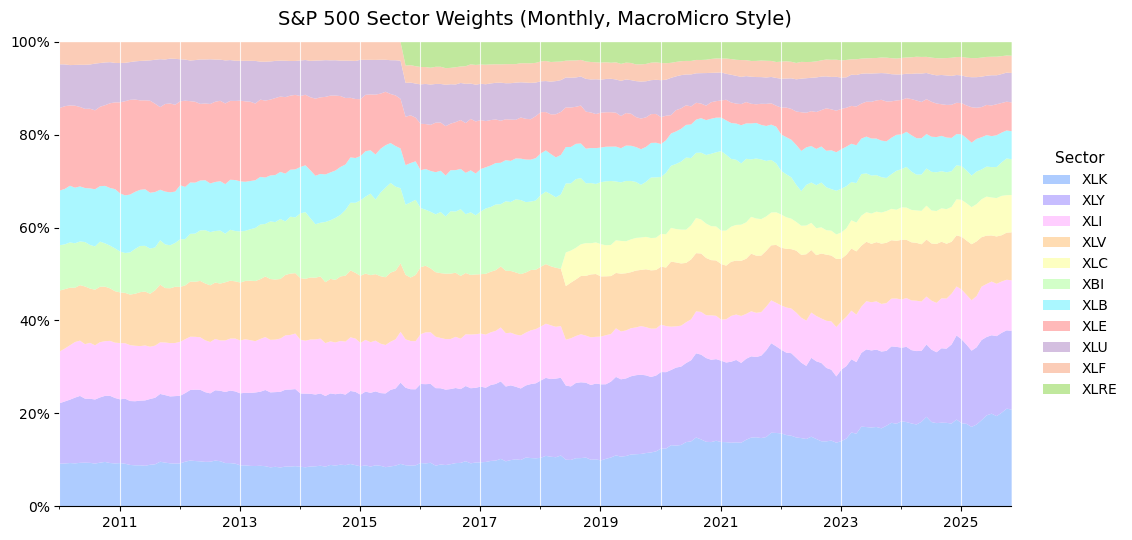

In [23]:
PALETTE = [
    "#A0C4FF", "#BDB2FF", "#FFC6FF", "#FFD6A5", "#FDFFB6",
    "#CAFFBF", "#9BF6FF", "#FFADAD", "#CDB4DB", "#FBC4AB", "#B5E48C"
]

def plot_sector_weights(
    weights: pd.DataFrame,
    title: str = "S&P 500 Sector Weights (Monthly, MacroMicro Style)",
    palette: list[str] = PALETTE,
    figsize: tuple[float, float] = (13, 5.5),
    facecolor: str = "#FFFFFF",
    legend_right: bool = True,
    save_path: str | None = os.path.join(FIGURE_DIR, "snp_sector_index.png"),
) -> tuple[plt.Figure, plt.Axes]:
    """Plot monthly sector weights as an area chart (0–100% y-axis)."""

    plt.style.use("default")

    # Ensure datetime index and row-wise normalization (sum=1)
    w = weights.copy()
    if not isinstance(w.index, pd.DatetimeIndex):
        w.index = pd.to_datetime(w.index)
    w = w.sort_index()
    rowsum = w.sum(axis=1).replace(0, np.nan)
    w = w.div(rowsum, axis=0).fillna(0.0)

    # Order columns by latest annual average weight
    wy = w.resample("Y").mean()
    order = wy.iloc[-1].sort_values(ascending=False).index
    w = w[order]

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    w.plot.area(ax=ax, linewidth=0, alpha=0.85, color=palette[:len(w.columns)])

    # Style
    ax.set_facecolor(facecolor)
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("", fontsize=12)
    ax.set_ylabel("", fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(axis="y", labelsize=10)

    # Year separators (Jan 1 each year)
    years = pd.date_range(w.index.min().normalize(), w.index.max().normalize(), freq="YS")
    for y in years:
        ax.axvline(y, color="white", linewidth=0.8, alpha=0.8)

    # Minimal axes
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.grid(False)

    # Legend
    if legend_right:
        ax.legend(
            loc="center left", bbox_to_anchor=(1.02, 0.5),
            frameon=False, fontsize=10, title="Sector", title_fontsize=11
        )
        plt.tight_layout(rect=[0, 0, 0.88, 1])
    else:
        ax.legend(loc="upper center", ncol=6, frameon=False, fontsize=10, bbox_to_anchor=(0.5, 1.1))
        plt.tight_layout()

    # Save
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor=facecolor)
        print(f"saved: {os.path.abspath(save_path)}")

    return fig, ax

fig, ax = plot_sector_weights(weights)



## **S&P 500 Figure**

/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2652150954.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, interval="1mo")["Close"]
[*********************100%***********************]  11 of 11 completed
/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2652150954.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w_lag = weights.shift(1).fillna(method="bfill")


saved: /Users/hoseung/GoogleDrive/3-2/Mathematical Economics/Assignment/report/figure/snp_index.png


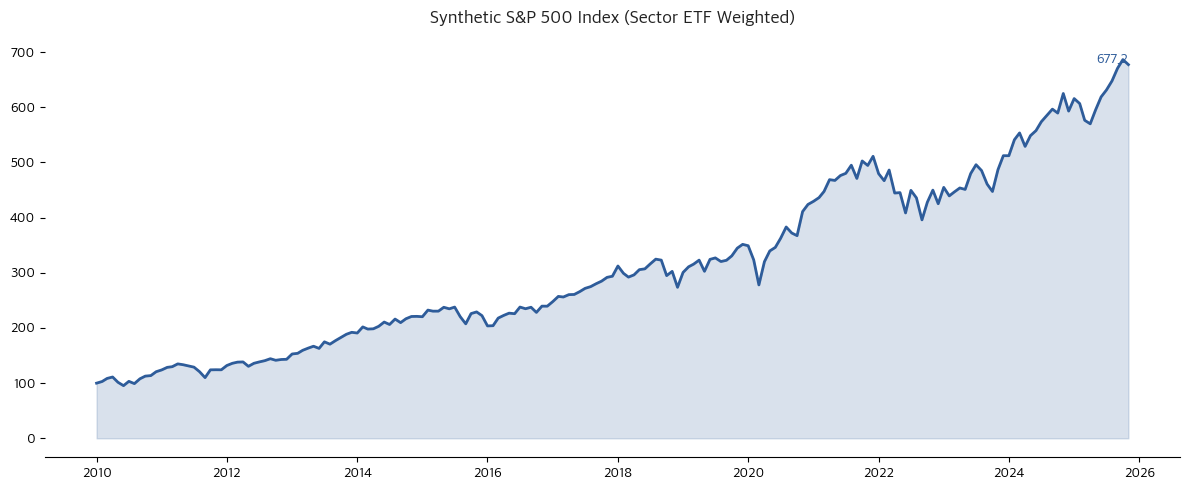

In [24]:

def download_monthly_prices(tickers: list[str], start: str = "2010-01-01") -> pd.DataFrame:
    df = yf.download(tickers, start=start, interval="1mo")["Close"]
    df = df.dropna(how="all").sort_index()
    df = df[~df.index.duplicated(keep="last")]
    return df


def price_weighted_weights(prices: pd.DataFrame) -> pd.DataFrame:
    w = prices.div(prices.sum(axis=1), axis=0).fillna(0.0)
    w = w.div(w.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    return w


def build_synthetic_index(prices: pd.DataFrame, weights: pd.DataFrame, base: float = 100.0) -> pd.Series:
    rets = prices.pct_change().fillna(0.0)
    w_lag = weights.shift(1).fillna(method="bfill")
    port_ret = (w_lag * rets).sum(axis=1)
    idx = (1 + port_ret).cumprod() * base
    return idx


def plot_spx_minimal(series: pd.Series,    save_path: str | None = os.path.join(FIGURE_DIR, "snp_index.png"),
                     font_family: str = "Apple SD Gothic Neo") -> None:
    plt.style.use("default")
    plt.rcParams.update({
        "font.family": font_family,
        "axes.unicode_minus": False,
    })

    fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
    ax.plot(series.index, series.values, color="#2E5C9A", linewidth=2.0)
    ax.fill_between(series.index, series.values, color="#2E5C9A", alpha=0.18)

    ax.set_title("Synthetic S&P 500 Index (Sector ETF Weighted)", fontsize=13, pad=12, color="#222")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(False)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

    last_val = float(series.iloc[-1])
    ax.text(series.index[-1], last_val, f"{last_val:,.1f}",
            ha="right", va="bottom", fontsize=10, color="#2E5C9A")

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"saved: {os.path.abspath(save_path)}")
    plt.show()


if __name__ == "__main__":
    TICKERS = ["XLK","XLF","XLV","XLY","XLI","XLE","XLC","XLU","XLB","XLRE","XBI"]

    prices = download_monthly_prices(TICKERS, start="2010-01-01")
    weights = price_weighted_weights(prices)
    spx_synthetic = build_synthetic_index(prices, weights, base=100)

    plot_spx_minimal(spx_synthetic)

/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2652150954.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, interval="1mo")["Close"]
[*********************100%***********************]  11 of 11 completed
/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2652150954.py:16: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w_lag = weights.shift(1).fillna(method="bfill")


saved: /Users/hoseung/GoogleDrive/3-2/Mathematical Economics/Assignment/report/figure/snp_index.png


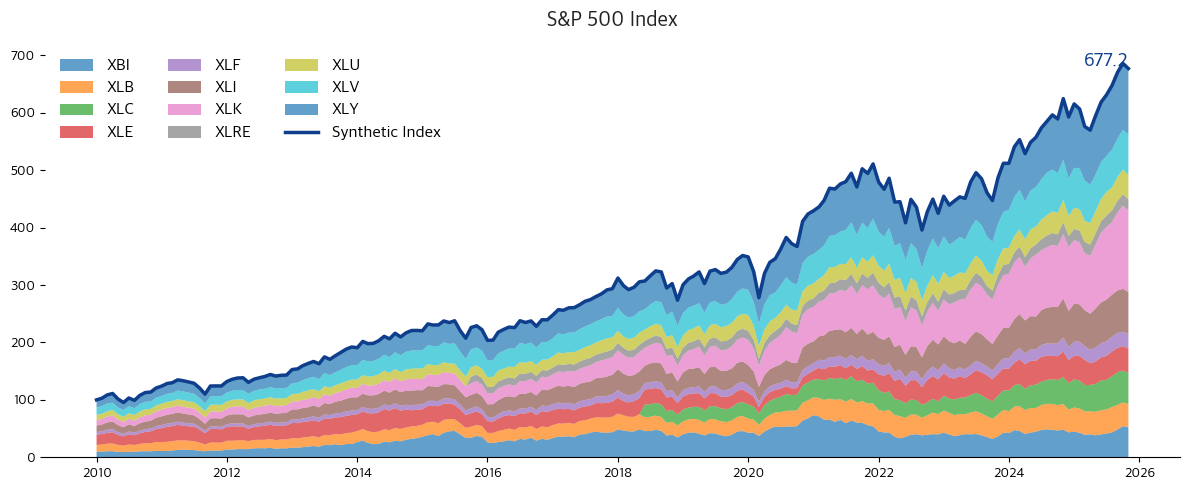

In [43]:
def plot_spx_cdf_in_index(series: pd.Series, weights: pd.DataFrame,
                          save_path: str | None =os.path.join(FIGURE_DIR, "snp_index.png"),
                          font_family: str = "Apple SD Gothic Neo") -> None:
    plt.style.use("default")
    plt.rcParams.update({
        "font.family": font_family,
        "axes.unicode_minus": False,
    })

    fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")

    # 각 ETF별로 '지수 내 비중 반영값' 계산
    weighted_levels = weights.mul(series, axis=0)

    # 누적 채움 (지수 전체 안에서 비중 비율로 표현)
    colors = plt.cm.tab10.colors[:weighted_levels.shape[1]]
    ax.stackplot(weighted_levels.index, weighted_levels.T,
                 colors=colors, alpha=0.7, labels=weighted_levels.columns)

    # 합(= synthetic index) 선 위에 표시
    ax.plot(series.index, series.values, color="#0E3E8C", linewidth=2.5, label="Synthetic Index", zorder=3)

    # 스타일
    ax.set_title("S&P 500 Index", fontsize=15, pad=12, color="#222")
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(False)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

    # 마지막 값 표시
    last_val = float(series.iloc[-1])
    ax.text(series.index[-1], last_val, f"{last_val:,.1f}", ha="right", va="bottom", fontsize=14, color="#0E3E8C")

    ax.legend(fontsize=14, ncol=3, frameon=False, loc="upper left")

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"saved: {os.path.abspath(save_path)}")
    plt.show()


if __name__ == "__main__":
    TICKERS = ["XLK","XLF","XLV","XLY","XLI","XLE","XLC","XLU","XLB","XLRE","XBI"]

    prices = download_monthly_prices(TICKERS, start="2010-01-01")
    weights = price_weighted_weights(prices)
    spx_synthetic = build_synthetic_index(prices, weights, base=100)

    # 그래프 출력
    plot_spx_cdf_in_index(spx_synthetic, weights)


In [48]:

# ---------------------------------------------------
# 0. 데이터 다운로드 및 수익률 계산
# ---------------------------------------------------
tickers = ["XLK","XLF","XLV","XLY","XLI","XLE","XLC","XLU","XLB","XLRE","XBI"]

data = yf.download(tickers, start="2010-01-01", interval="1mo")["Close"]
data = data.dropna(how="all")

returns_df = data.pct_change().dropna()

mu_vec = returns_df.mean().values
cov_mat = returns_df.cov().values
tickers = list(returns_df.columns)
n_players = len(tickers)

def _min_variance(Sigma):
    k = Sigma.shape[0]
    def obj(w): return w @ Sigma @ w
    x0 = np.ones(k) / k
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0.0, 1.0)] * k
    res = minimize(obj, x0, method='SLSQP', bounds=bounds, constraints=cons)
    if not res.success:
        w = np.ones(k) / k
        return w @ Sigma @ w
    return res.fun


def _max_mean_variance(mu, Sigma, lam):
    k = Sigma.shape[0]
    def obj(w): return -(mu @ w - lam * (w @ Sigma @ w))
    x0 = np.ones(k) / k
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds = [(0.0, 1.0)] * k
    res = minimize(obj, x0, method='SLSQP', bounds=bounds, constraints=cons)
    if not res.success:
        w = np.ones(k) / k
        return mu @ w - lam * (w @ Sigma @ w)
    return -res.fun

def v_risk(S, cov_mat):
    if len(S) == 0: return 0.0
    idx = np.array(sorted(list(S)))
    Sigma_SS = cov_mat[np.ix_(idx, idx)]
    indiv_var_sum = np.diag(Sigma_SS).sum()
    min_var = _min_variance(Sigma_SS)
    return indiv_var_sum - min_var


def v_mv(S, mu_vec, cov_mat, lam=3.0):
    if len(S) == 0: return 0.0
    idx = np.array(sorted(list(S)))
    mu_S = mu_vec[idx]
    Sigma_SS = cov_mat[np.ix_(idx, idx)]
    return _max_mean_variance(mu_S, Sigma_SS, lam)

def _one_sample(v_func, n_players, rng_seed, log_flag=False, **v_kwargs):
    rng = np.random.default_rng(rng_seed)
    players = np.arange(n_players)
    perm = rng.permutation(players)
    S = set()
    v_S = 0.0
    contrib = np.zeros(n_players)
    logs = []
    for i in perm:
        v_before = v_S
        S_with_i = S | {int(i)}
        v_after = v_func(S_with_i, **v_kwargs)
        marginal = v_after - v_before
        contrib[i] += marginal
        if log_flag:
            logs.append({
                "player": int(i),
                "coalition_size": len(S),
                "marginal_contribution": marginal,
                "coalition": tuple(sorted(list(S))),
            })
        S = S_with_i
        v_S = v_after
    if log_flag:
        return contrib, logs
    else:
        return contrib

def shapley_parallel_with_log(v_func, n_players, n_samples=1000, random_state=0, n_jobs=-1, **v_kwargs):
    rng_master = np.random.default_rng(random_state)
    seeds = rng_master.integers(0, 1_000_000_000, size=n_samples)
    results = Parallel(n_jobs=n_jobs)(
        delayed(_one_sample)(
            v_func=v_func,
            n_players=n_players,
            rng_seed=int(seeds[k]),
            log_flag=True,
            **v_kwargs
        )
        for k in range(n_samples)
    )
    phi = np.zeros(n_players)
    log_records = []
    for contrib, logs in results:
        phi += contrib
        log_records.extend(logs)
    phi /= n_samples
    log_df = pd.DataFrame(log_records)
    return phi, log_df

phi_risk, log_risk = shapley_parallel_with_log(
    v_func=v_risk,
    n_players=n_players,
    n_samples=3000,
    random_state=42,
    n_jobs=-1,
    cov_mat=cov_mat
)

phi_mv, log_mv = shapley_parallel_with_log(
    v_func=v_mv,
    n_players=n_players,
    n_samples=3000,
    random_state=43,
    n_jobs=-1,
    mu_vec=mu_vec,
    cov_mat=cov_mat,
    lam=3.0
)

log_risk["type"] = "risk"
log_mv["type"]   = "mv"
logs_df = pd.concat([log_risk, log_mv], ignore_index=True)
logs_df["ticker"] = logs_df["player"].map(lambda i: tickers[i])

shapley_df = pd.DataFrame({
    "phi_risk": phi_risk,
    "phi_mv": phi_mv
}, index=tickers)

print("=== Shapley 값 요약 ===")
print(shapley_df)

risk_logs = logs_df.query("type == 'risk'").copy()
mv_logs   = logs_df.query("type == 'mv'").copy()

risk_top_by_ticker = (
    risk_logs
    .sort_values("marginal_contribution", ascending=False)
    .groupby("ticker", as_index=False)
    .head(1)
)

mv_top_by_ticker = (
    mv_logs
    .sort_values("marginal_contribution", ascending=False)
    .groupby("ticker", as_index=False)
    .head(1)
)



avg_marginal_risk = logs_df.query("type == 'risk'").groupby("ticker")["marginal_contribution"].mean()
avg_marginal_mv   = logs_df.query("type == 'mv'").groupby("ticker")["marginal_contribution"].mean()

avg_marginal_df = pd.DataFrame({
    "phi_risk": avg_marginal_risk,
    "phi_mv": avg_marginal_mv
}).fillna(0)

print("\n=== 섹터별 평균 한계 기여도 (v_risk, v_mv 기준) ===")
print(avg_marginal_df)



/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2029235090.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01", interval="1mo")["Close"]
[*********************100%***********************]  11 of 11 completed


=== Shapley 값 요약 ===
      phi_risk    phi_mv
XBI   0.005941 -0.001178
XLB   0.003389  0.000073
XLC   0.003111  0.001048
XLE   0.008544 -0.001495
XLF   0.003598  0.000439
XLI   0.003393  0.000674
XLK   0.003601  0.005212
XLRE  0.002982  0.000113
XLU   0.002756  0.001963
XLV   0.002495  0.001465
XLY   0.004051  0.000306

=== 섹터별 평균 한계 기여도 (v_risk, v_mv 기준) ===
        phi_risk    phi_mv
ticker                    
XBI     0.005941 -0.001178
XLB     0.003389  0.000073
XLC     0.003111  0.001048
XLE     0.008544 -0.001495
XLF     0.003598  0.000439
XLI     0.003393  0.000674
XLK     0.003601  0.005212
XLRE    0.002982  0.000113
XLU     0.002756  0.001963
XLV     0.002495  0.001465
XLY     0.004051  0.000306


In [10]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.optimize import minimize
from joblib import Parallel, delayed

# ---------------------------------------------------
# 0. 데이터 다운로드 및 수익률 계산
# ---------------------------------------------------
tickers = ["XLK","XLF","XLV","XLY","XLI","XLE","XLC","XLU","XLB","XLRE","XBI"]

data = yf.download(tickers, start="2010-01-01", interval="1mo")["Close"]
data = data.dropna(how="all")                      # 전처리
returns_df = data.pct_change().dropna()            # 월별 수익률

n_players = len(tickers)

# ---------------------------------------------------
# 1. 최적화 헬퍼 함수
# ---------------------------------------------------
def _min_variance(Sigma):
    """min_w w'Σw  s.t. w >= 0, sum w = 1"""
    k = Sigma.shape[0]

    def obj(w):
        return w @ Sigma @ w

    x0 = np.ones(k) / k
    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0.0, 1.0)] * k

    res = minimize(obj, x0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        w = np.ones(k) / k
        return w @ Sigma @ w
    return res.fun


def _max_mean_variance(mu, Sigma, lam):
    """max_w mu'w - lam * w'Σw  s.t. w >= 0, sum w = 1"""
    k = Sigma.shape[0]

    def obj(w):
        return -(mu @ w - lam * (w @ Sigma @ w))

    x0 = np.ones(k) / k
    cons = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
    bounds = [(0.0, 1.0)] * k

    res = minimize(obj, x0, method="SLSQP", bounds=bounds, constraints=cons)
    if not res.success:
        w = np.ones(k) / k
        return mu @ w - lam * (w @ Sigma @ w)
    return -res.fun

# ---------------------------------------------------
# 2. 가치함수 v_risk, v_mv
# ---------------------------------------------------
def v_risk(S, cov_mat):
    """위험 감소 기반 가치함수 v_risk(S)"""
    if len(S) == 0:
        return 0.0
    idx = np.array(sorted(list(S)))
    Sigma_SS = cov_mat[np.ix_(idx, idx)]

    indiv_var_sum = np.diag(Sigma_SS).sum()
    min_var = _min_variance(Sigma_SS)
    return indiv_var_sum - min_var


def v_mv(S, mu_vec, cov_mat, lam=3.0):
    """평균–분산 기반 가치함수 v_mv(S)"""
    if len(S) == 0:
        return 0.0
    idx = np.array(sorted(list(S)))
    mu_S = mu_vec[idx]
    Sigma_SS = cov_mat[np.ix_(idx, idx)]
    return _max_mean_variance(mu_S, Sigma_SS, lam)

# ---------------------------------------------------
# 3. Shapley 샘플 1회 (로그 포함)
# ---------------------------------------------------
def _one_sample_with_log(v_func, n_players, rng_seed, **v_kwargs):
    rng = np.random.default_rng(rng_seed)
    players = np.arange(n_players)
    perm = rng.permutation(players)

    S = set()
    v_S = 0.0
    contrib = np.zeros(n_players)
    logs = []

    for i in perm:
        v_before = v_S
        S_with_i = S | {int(i)}
        v_after = v_func(S_with_i, **v_kwargs)
        marginal = v_after - v_before

        contrib[i] += marginal

        logs.append({
            "player": int(i),
            "coalition_size": len(S),
            "marginal_contribution": marginal,
            "coalition": tuple(sorted(list(S))),
        })

        S = S_with_i
        v_S = v_after

    return contrib, logs

# ---------------------------------------------------
# 4. 병렬 Shapley + 로그 (한 윈도우에 대해)
# ---------------------------------------------------
def shapley_parallel_with_log(v_func,
                              n_players,
                              n_samples=300,
                              random_state=0,
                              n_jobs=-1,
                              **v_kwargs):
    rng_master = np.random.default_rng(random_state)
    seeds = rng_master.integers(0, 1_000_000_000, size=n_samples)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_one_sample_with_log)(
            v_func=v_func,
            n_players=n_players,
            rng_seed=int(seeds[k]),
            **v_kwargs
        )
        for k in range(n_samples)
    )

    phi = np.zeros(n_players)
    log_records = []
    for contrib, logs in results:
        phi += contrib
        log_records.extend(logs)

    phi /= n_samples
    log_df = pd.DataFrame(log_records)
    return phi, log_df

# ---------------------------------------------------
# 5. 롤링 윈도우(36개월) Shapley + 로그 계산 (병렬 샘플)
# ---------------------------------------------------
window = 36  # 36개월 롤링창
dates = []
phi_risk_list = []
phi_mv_list = []
logs_all = []

for t in range(window, len(returns_df)):
    sub = returns_df.iloc[t - window : t]
    mu = sub.mean().values
    cov = sub.cov().values
    current_date = returns_df.index[t]

    # 위험 감소 기반 Shapley (병렬)
    phi_r, log_r = shapley_parallel_with_log(
        v_func=v_risk,
        n_players=n_players,
        n_samples=300,
        random_state=42 + t,   # 윈도우마다 seed 변화
        n_jobs=-1,
        cov_mat=cov,
    )

    # 평균–분산 기반 Shapley (병렬)
    phi_m, log_m = shapley_parallel_with_log(
        v_func=v_mv,
        n_players=n_players,
        n_samples=300,
        random_state=84 + t,
        n_jobs=-1,
        mu_vec=mu,
        cov_mat=cov,
    )

    phi_risk_list.append(phi_r)
    phi_mv_list.append(phi_m)
    dates.append(current_date)

    # 로그에 날짜/타입/티커 정보 추가
    log_r["date"] = current_date
    log_r["type"] = "risk"
    log_m["date"] = current_date
    log_m["type"] = "mv"

    logs_all.append(log_r)
    logs_all.append(log_m)

# ---------------------------------------------------
# 6. 결과 DataFrame 구성
# ---------------------------------------------------
phi_risk_df = pd.DataFrame(phi_risk_list, columns=tickers, index=dates)
phi_mv_df   = pd.DataFrame(phi_mv_list,   columns=tickers, index=dates)

logs_df = pd.concat(logs_all, ignore_index=True)
logs_df["ticker"] = logs_df["player"].map(lambda i: tickers[i])

print(phi_risk_df.tail())
print(phi_mv_df.tail())
print(logs_df.head())


/var/folders/9d/zp_kbg350bs7j_821_pnhb7r0000gn/T/ipykernel_58619/2695198535.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2010-01-01", interval="1mo")["Close"]
[*********************100%***********************]  11 of 11 completed


                 XLK       XLF       XLV       XLY       XLI       XLE  \
2025-07-01  0.004433  0.003042  0.002702  0.004765  0.002923  0.002926   
2025-08-01  0.004248  0.003097  0.002602  0.004592  0.002789  0.002812   
2025-09-01  0.004460  0.003127  0.002445  0.004455  0.002751  0.002803   
2025-10-01  0.004548  0.002735  0.002192  0.004127  0.002580  0.002391   
2025-11-01  0.004676  0.002598  0.002055  0.002608  0.002333  0.001966   

                 XLC       XLU       XLB      XLRE       XBI  
2025-07-01  0.003883  0.003446  0.002617  0.002253  0.004325  
2025-08-01  0.003233  0.003158  0.002557  0.002222  0.003716  
2025-09-01  0.003227  0.003018  0.002525  0.002116  0.003678  
2025-10-01  0.002814  0.002507  0.002161  0.001803  0.003330  
2025-11-01  0.002835  0.002593  0.002031  0.001679  0.003332  
                 XLK       XLF       XLV       XLY       XLI       XLE  \
2025-07-01 -0.000812  0.000085  0.005843 -0.000205  0.002214  0.002198   
2025-08-01 -0.000863 -0.00016

In [12]:
logs_df.to_csv("shapley_logs.csv", index=False, encoding="utf-8-sig")
print("\n✅ logs_df가 'shapley_logs.csv' 파일로 저장되었습니다.")


✅ logs_df가 'shapley_logs.csv' 파일로 저장되었습니다.


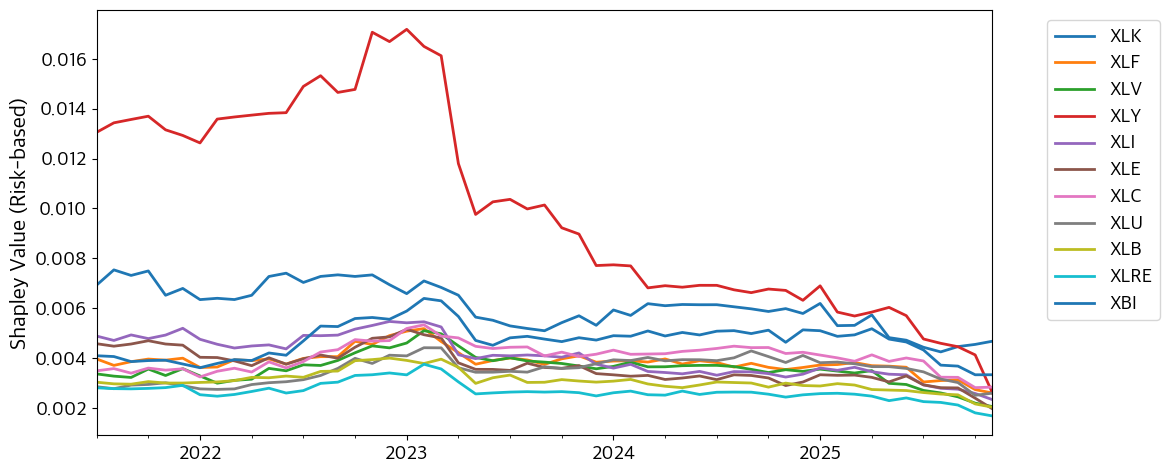

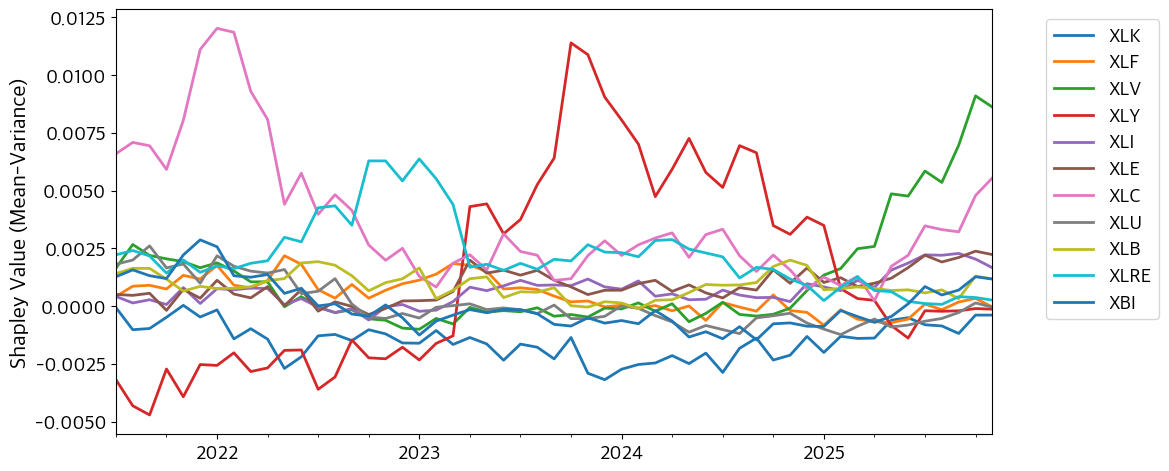

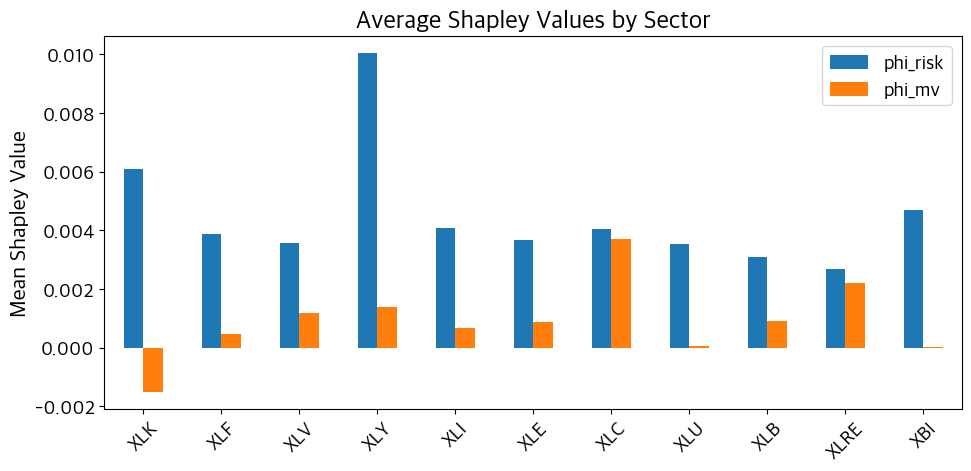

<Figure size 1800x900 with 0 Axes>

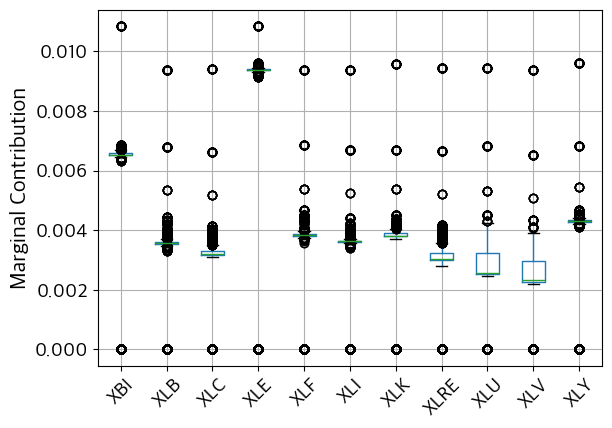

<Figure size 1800x900 with 0 Axes>

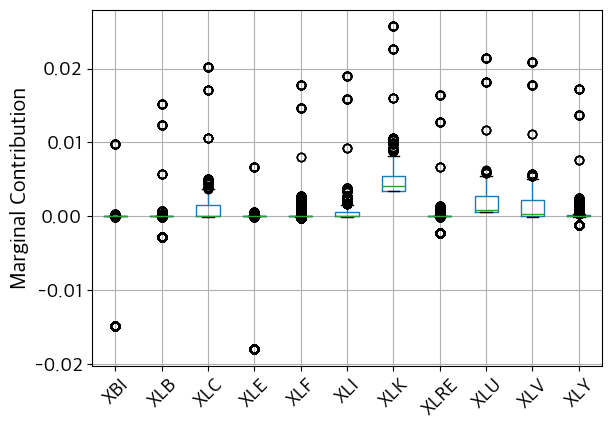

In [54]:
import matplotlib.pyplot as plt
import os
import pandas as pd

# ---------------------------------------------------
# 전역 폰트 크기 설정
# ---------------------------------------------------
plt.rcParams.update({
    'font.size': 16,         # 기본 글자 크기
    'axes.titlesize': 18,    # 그래프 제목
    'axes.labelsize': 16,    # 축 라벨
    'xtick.labelsize': 14,   # X축 눈금
    'ytick.labelsize': 14,   # Y축 눈금
    'legend.fontsize': 14,   # 범례
    'figure.titlesize': 20   # 전체 Figure 제목
})

# ---------------------------------------------------
# 저장 경로 설정
# ---------------------------------------------------
save_path = FIGURE_DIR
os.makedirs(save_path, exist_ok=True)

# ---------------------------------------------------
# 1️⃣ 시계열 그래프
# ---------------------------------------------------
plt.figure(figsize=(12,5))
phi_risk_df.plot(ax=plt.gca(), linewidth=2)
plt.ylabel("Shapley Value (Risk-based)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "rolling_shapley_v_risk.png"), dpi=300)
plt.show()

plt.figure(figsize=(12,5))
phi_mv_df.plot(ax=plt.gca(), linewidth=2)
plt.ylabel("Shapley Value (Mean-Variance)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "rolling_shapley_v_mv.png"), dpi=300)
plt.show()

# ---------------------------------------------------
# 2️⃣ 섹터별 평균 Shapley 값 막대그래프
# ---------------------------------------------------
avg_phi = pd.DataFrame({
    "phi_risk": phi_risk_df.mean(),
    "phi_mv": phi_mv_df.mean()
})
avg_phi.plot(kind="bar", figsize=(10,5))
plt.title("Average Shapley Values by Sector")
plt.ylabel("Mean Shapley Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(save_path, "average_shapley_values.png"), dpi=300)
plt.show()


plt.figure(figsize=(18, 9))
ax = logs_df.query("type == 'risk'").boxplot(
    column="marginal_contribution", by="ticker", rot=45
)
plt.suptitle("")   # 상단 기본 제목 제거
ax.set_title("")   # 그룹별 제목 제거
plt.ylabel("Marginal Contribution")
plt.xlabel("")     # 불필요한 x축 레이블 제거
plt.tight_layout()
plt.savefig(os.path.join(save_path, "boxplot_v_risk.png"), dpi=300)
plt.show()

# 평균–분산 기준 박스플롯
plt.figure(figsize=(18, 9))
ax = logs_df.query("type == 'mv'").boxplot(
    column="marginal_contribution", by="ticker", rot=45
)
plt.suptitle("")
ax.set_title("")
plt.ylabel("Marginal Contribution")
plt.xlabel("")
plt.tight_layout()
plt.savefig(os.path.join(save_path, "boxplot_v_mv.png"), dpi=300)
plt.show()

